Лабораторная работа №6 (Измерение мю ритмов)

Касьяненко Вера и Кремпольская Екатерина

P3420

Импорт необходимых библиотек:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, welch

try:
    from IPython.display import display
except Exception:
    display = print

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 6)

Загрузка наших изменений.

1. Покой
2. Представление движения
3. Рисование
4. Программирование



In [ ]:
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1UAaW27umXKHTAjtmHtT5ivnc3IAcnqCM' -O 1.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1s6PYQ2wAuK7MiuNdMoTI-u-blYHvkgse' -O 2.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1T0HtHAbK6Xzs8HNaVMbeobgTsag1T5Ne' -O 3.csv
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1rpBkqzLn8hQ1lYQ-9RHxnvws5wqfcHZQ' -O 4.csv

Настройки

In [ ]:
CONDITIONS = [
    ("Покой",                  "1.csv"),
    ("Представление движения", "2.csv"),
    ("Рисование",              "3.csv"),
    ("Движение руками",        "4.csv"),
]

MU_BAND = (8.0, 13.0)

## Загрузка файла и оценка частоты дискретизации (Fs)

In [ ]:
# Загрузка и Fs
def load_eeg_file(file_path: str, verbose: bool = True):
    df = pd.read_csv(file_path, encoding="utf-8")

    t = df.iloc[:, 0].astype(float).to_numpy()

    # делаем от 0, сортируем, убираем дубли
    t = np.unique(np.sort(t - t[0]))

    # оцениваем Fs
    dt = np.diff(t)
    dt = dt[dt > 0]
    fs = 1 / np.median(dt) if dt.size else np.nan

    return df, float(fs)


## Подготовка сигнала

- усредняем значения сигнала на одинаковом времени,
- ограничиваем сильные выбросы,
- нормируем сигнал

In [ ]:
# Подготовка сигнала
def preprocess_signal(df: pd.DataFrame, channel: str):
    t_col = df.columns[0]

    tmp = df[[t_col, channel]].dropna().copy()
    tmp[t_col] = tmp[t_col].astype(float)
    tmp[channel] = tmp[channel].astype(float)

    # усредняем сигнал на одинаковом времени
    tmp = (
        tmp.groupby(t_col, as_index=False)[channel]
           .mean()
           .sort_values(t_col)
           .reset_index(drop=True)
    )

    time = tmp[t_col].to_numpy()
    sig = tmp[channel].to_numpy()

    # обрезаем сильные выбросы
    mu = np.mean(sig)
    sd = np.std(sig) if np.std(sig) != 0 else 1.0
    sig_clip = np.clip(sig, mu - 3 * sd, mu + 3 * sd)

    # нормируем
    sig_norm = (sig_clip - np.mean(sig_clip)) / (np.std(sig_clip) if np.std(sig_clip) != 0 else 1.0)

    return time, sig_norm

def pick_channel(df: pd.DataFrame) -> str:
    c = df.columns[1]
    if pd.api.types.is_numeric_dtype(df[c]):
        return c

    for c in df.columns[1:]:
        if pd.api.types.is_numeric_dtype(df[c]):
            return c

## Полосовой фильтр (8-13 Гц)

In [ ]:
# Полосовой фильтр
def apply_bandpass_filter(x: np.ndarray, low: float, high: float, fs: float, order: int = 4) -> np.ndarray:
    nyq = 0.5 * fs
    low_n = low / nyq
    high_n = high / nyq
    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, x)


## Анализ mu-ритма (PSD + доля)

Считаем:
- PSD через Welch,
- mu_power - площадь PSD в 8-13 Гц,
- mu_ratio - доля mu_power от общей мощности PSD

Графики:
- слева: сигнал + mu-компонента,
- справа: PSD с выделенной mu-полосой.


In [ ]:
# Анализ mu
def analyze_mu_rhythm(time: np.ndarray, signal: np.ndarray, fs: float, condition_name: str, plot: bool = True):
    # mu-сигнал только для визуализации
    mu_signal = apply_bandpass_filter(signal, MU_BAND[0], MU_BAND[1], fs)

    # PSD Welch
    freqs, psd = welch(signal, fs=fs, nperseg=min(1024, len(signal)))

    mu_mask = (freqs >= MU_BAND[0]) & (freqs <= MU_BAND[1])

    total_power = np.trapezoid(psd, freqs)
    mu_power = np.trapezoid(psd[mu_mask], freqs[mu_mask]) if np.any(mu_mask) else 0.0
    mu_ratio = (mu_power / total_power) if total_power > 0 else 0.0

    dominant_mu_freq = np.nan
    if np.any(mu_mask):
        dominant_mu_freq = float(freqs[mu_mask][np.argmax(psd[mu_mask])])

    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

        ax1.plot(time, signal, linewidth=0.9, alpha=0.8)
        ax1.plot(time, mu_signal, label="mu (8-13 Гц)", linewidth=1.2)
        ax1.set_title(f"{condition_name}: сигнал и mu-компонента")
        ax1.set_xlabel("Время, с")
        ax1.set_ylabel("у.е.")
        ax1.grid(alpha=0.3)
        ax1.legend()

        ax2.plot(freqs, psd, linewidth=1.2)
        ax2.axvspan(MU_BAND[0], MU_BAND[1], alpha=0.2, label="mu 8-13 Гц")
        ax2.set_xlim(0, 30)
        ax2.set_title(f"{condition_name}: PSD (Welch)")
        ax2.set_xlabel("Гц")
        ax2.set_ylabel("PSD")
        ax2.grid(alpha=0.3)
        ax2.legend()

        plt.tight_layout()
        plt.show()

    return {
        "condition": condition_name,
        "mu_power": float(mu_power),
        "mu_ratio": float(mu_ratio),
        "dominant_mu_freq": dominant_mu_freq
    }


## Прогон по всем условиям


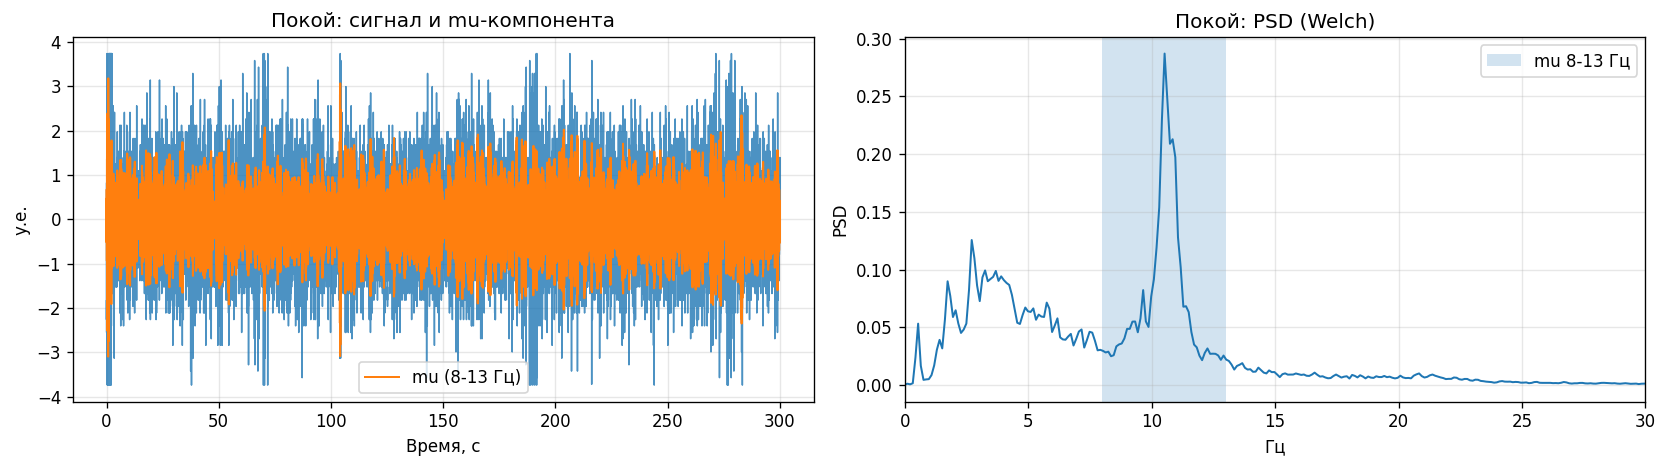

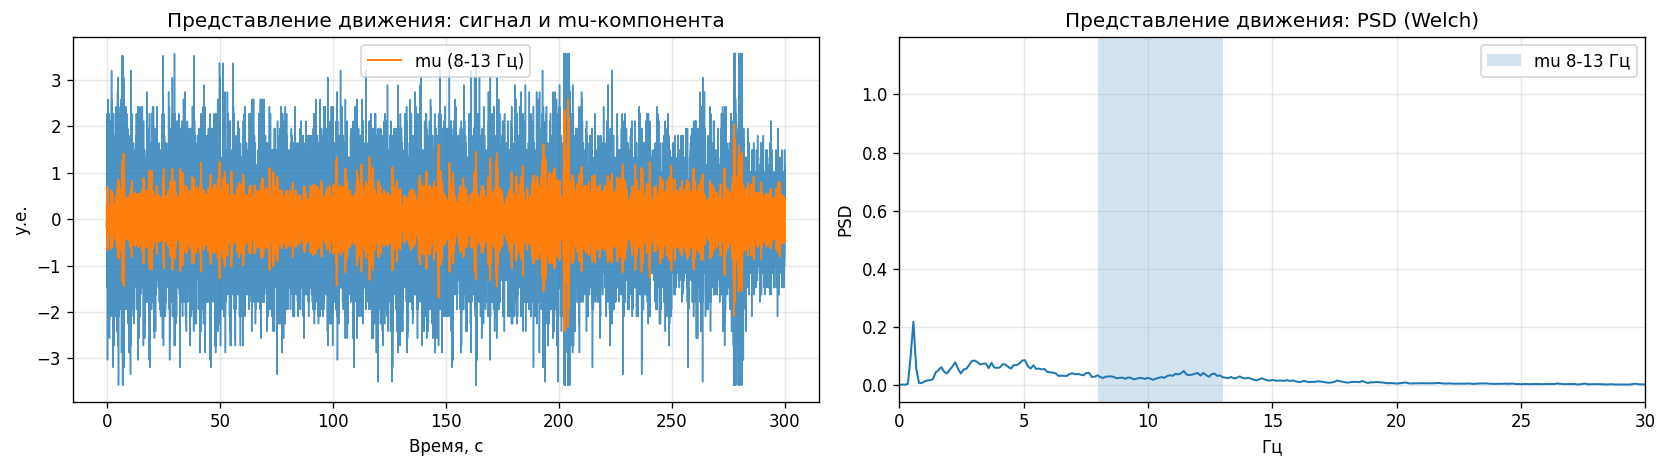

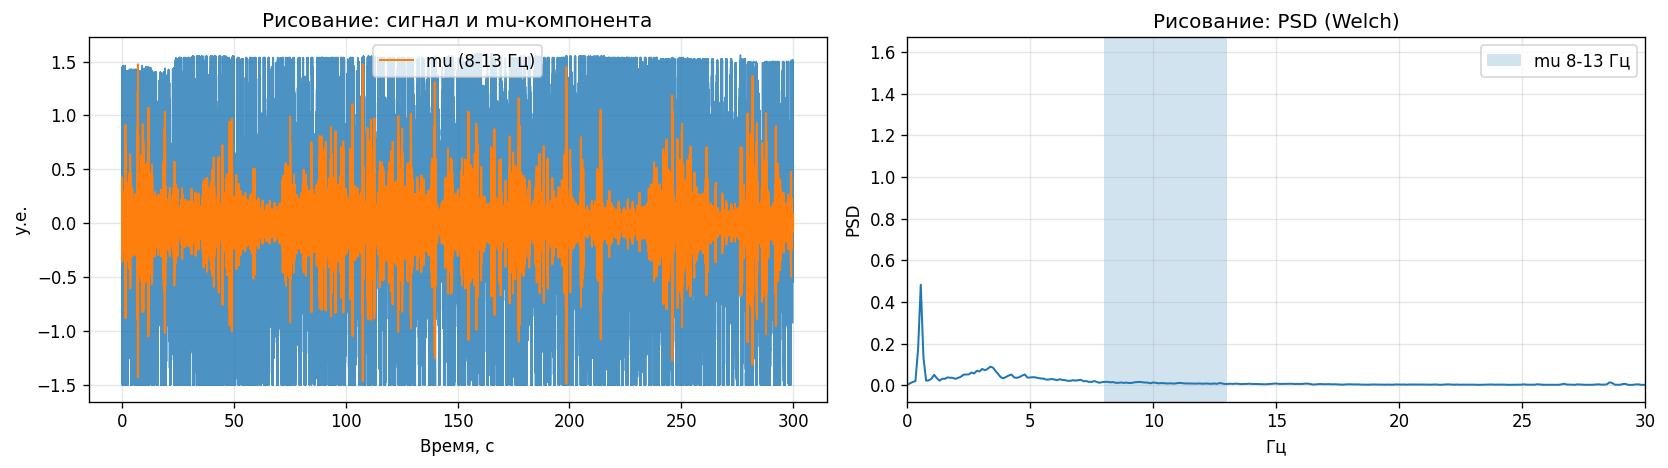

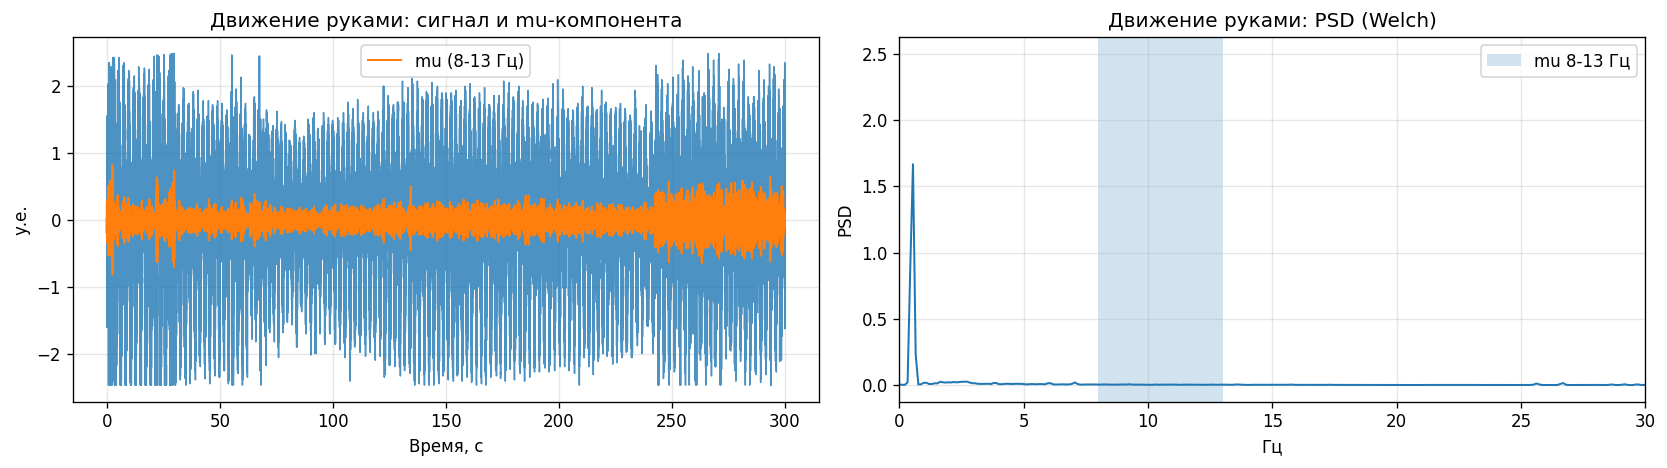

,condition,mu_power,mu_ratio,dominant_mu_freq
0,Покой,0.367596,0.385827,10.524821
1,Представление движения,0.145365,0.145354,11.435860
2,Рисование,0.050818,0.050876,8.137964
3,Движение руками,0.016852,0.017049,9.223026


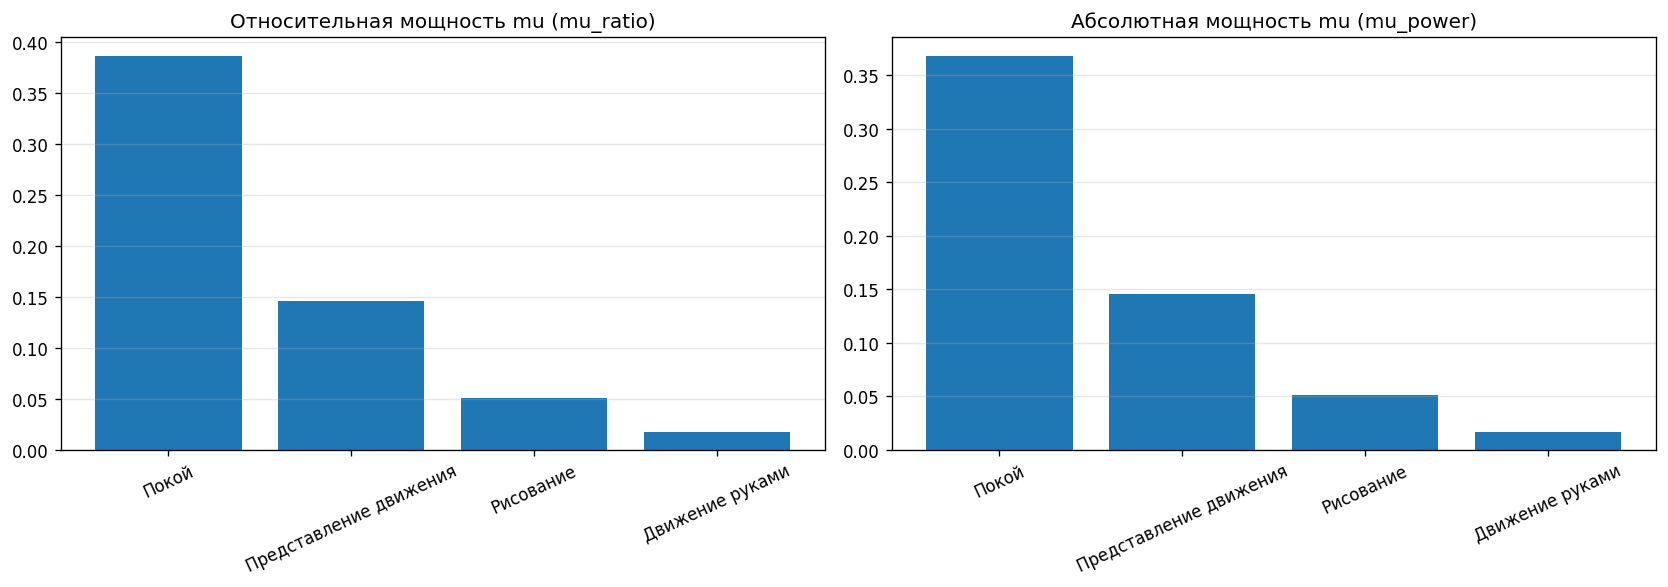

In [ ]:
# Запуск анализа
processed_results = []

for cond_name, fp in CONDITIONS:
    df, fs = load_eeg_file(fp, verbose=True)

    ch = pick_channel(df)
    t, sig = preprocess_signal(df, channel=ch)

    res = analyze_mu_rhythm(t, sig, fs=fs, condition_name=cond_name, plot=True)
    processed_results.append(res)

if processed_results:
    results_df = pd.DataFrame(processed_results)
    display(results_df)

    # сортировка по доле mu
    results_df = results_df.sort_values("mu_ratio", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].bar(results_df["condition"], results_df["mu_ratio"])
    ax[0].set_title("Относительная мощность mu (mu_ratio)")
    ax[0].tick_params(axis="x", rotation=25)
    ax[0].grid(axis="y", alpha=0.3)

    ax[1].bar(results_df["condition"], results_df["mu_power"])
    ax[1].set_title("Абсолютная мощность mu (mu_power)")
    ax[1].tick_params(axis="x", rotation=25)
    ax[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


## Сравнение с состоянием "Покой"

Берем состояние "Покой" как базу и считаем:
- насколько изменилась мощность mu,
- насколько изменилась доля mu

In [ ]:
# База и изменения
if processed_results:
    baseline_idx = None
    for i, r in results_df.iterrows():
        s = str(r["condition"]).lower()
        if ("покой" in s) or ("rest" in s):
            baseline_idx = i
            break

    if baseline_idx is None:
        baseline_idx = 0

    baseline_condition = results_df.loc[baseline_idx, "condition"]
    baseline_power = results_df.loc[baseline_idx, "mu_power"]
    baseline_ratio = results_df.loc[baseline_idx, "mu_ratio"]

    print(f"\nБазовое состояние: «{baseline_condition}»")
    print(f"Мощность mu в базе: {baseline_power:.6f}")
    print(f"Доля mu в базе:     {baseline_ratio:.2%}")

    final_df = results_df.copy()
    final_df["Изменение мощности, %"] = final_df.apply(
        lambda row: ((row["mu_power"] - baseline_power) / baseline_power * 100) if baseline_power > 0 else 0,
        axis=1
    )
    final_df["Изменение доли, %"] = final_df.apply(
        lambda row: ((row["mu_ratio"] - baseline_ratio) / baseline_ratio * 100) if baseline_ratio > 0 else 0,
        axis=1
    )

    display(final_df[["condition", "mu_ratio", "dominant_mu_freq", "Изменение мощности, %", "Изменение доли, %"]].round(4))

    max_row = final_df.loc[final_df["mu_ratio"].idxmax()]
    min_row = final_df.loc[final_df["mu_ratio"].idxmin()]

    print(f"\nНаиболее выраженный mu-ритм:")
    print(f"   Состояние: «{max_row['condition']}»")
    print(f"   Относительная мощность: {max_row['mu_ratio']:.2%}")

    print(f"\nНаименее выраженный mu-ритм:")
    print(f"   Состояние: «{min_row['condition']}»")
    print(f"   Относительная мощность: {min_row['mu_ratio']:.2%}")



Базовое состояние: «Покой»
Мощность mu в базе: 0.367596
Доля mu в базе:     38.58%


,condition,mu_ratio,dominant_mu_freq,"Изменение мощности, %","Изменение доли, %"
0,Покой,0.3858,10.5248,0.0000,0.0000
1,Представление движения,0.1454,11.4359,-60.4551,-62.3265
2,Рисование,0.0509,8.1380,-86.1755,-86.8138
3,Движение руками,0.0170,9.2230,-95.4157,-95.5812



Наиболее выраженный mu-ритм:
   Состояние: «Покой»
   Относительная мощность: 38.58%

Наименее выраженный mu-ритм:
   Состояние: «Движение руками»
   Относительная мощность: 1.70%


## Выводы

Максимальная мю-активность получилась в покое:
- mu_ratio = 0.3858 (38.58%)
- mu_power = 0.3676

Минимальная мю-активность - при движении руками:
- mu_ratio = 0.0170 (1.70%)
- mu_power = 0.0169

Порядок условий (от больше к меньше по мю):
1) Покой
2) Представление движения
3) Рисование
4) Движение руками

Если "Покой" принять за базу, то доля мю (mu_ratio) упала:
- Представление движения: на −62.33%
- Рисование: на −86.81%
- Движение руками: на −95.58%

Это хорошо совпадает с ожидаемым:
- В покое мю обычно выражен сильнее,
- При движениях (особенно реальных) мю заметно уменьшается,
- При представлении движения мю тоже снижается, но обычно не так сильно, как при реальном движении,
- "Рисование" - это уже активная работа руками, поэтому мю падает сильнее, чем при простом воображении движения.

Таким образом, мю-ритм максимален в покое и почти исчезает при реальном движении руками; воображаемое движение дает промежуточный эффект - это соответствует ожидаемому поведению мю-ритма.
